# 18_归一化方法-Z-score 标准化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这小节我们来聊聊归一化方法方面的Z-score 标准化\~

### 什么是归一化？

**归一化**是对数据进行**转换**的过程，目的是让不同量纲、不同单位的数据变得**可比**。

比如：

- 有一列身高数据，单位是「厘米」，范围是150\~190；
- 有一列体重数据，单位是「千克」，范围是45\~90。

它们的数值大小、分布范围完全不同，在做机器学习模型时，不做归一化会让模型受到高数值变量的主导，结果失衡。

### 什么是 Z-score 标准化？

Z-score 标准化，又叫**标准差标准化**，是将原始数据转换成**均值为0，标准差为1**的标准正态分布数据。

把每个数据和平均值比较一下，看它是「比平均高多少」或「比平均低多少」，然后用标准差来衡量这个差值「相对于整体来说有多大」。

比如说：

- 如果你考了90分，平均分是80，标准差是5；
- 那你比平均高10分，这比起5分的标准差来说，就高了 **2个标准差**；
- 所以你的 **Z-score = 2**。

这样一来，不管是身高、体重还是成绩，都能转换成一个统一标准，“它在本组数据中偏离平均多少”。

### Z-score 标准化的公式

标准化后的数据 $z$ 的计算公式如下：


$$
z = \frac{x - \mu}{\sigma}
$$


其中：

- $x$：原始数据值
- $\mu$：所有数据的**均值（平均数）**
- $\sigma$：所有数据的**标准差**

## 原理分析

### 1. 为什么要减去平均值？

我们希望知道：每个数据与“整体平均”相差多少。

$x - \mu$：代表这个数据比平均值多或少的程度（叫做「偏差」）

### 2. 为什么要除以标准差？

不同的数据集，数值范围不同。如果直接比较偏差值 $x - \mu$，无法公平衡量“偏离程度”。

- 所以我们用「标准差」来作为衡量单位，相当于问：这个数据与平均值的偏差，占了标准差的多少倍？

举个例子：

假设某班考试成绩如下（单位：分）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[60, 70, 80, 90, 100]
```

我们来算：

- 均值 $\mu = \frac{60 + 70 + 80 + 90 + 100}{5} = 80$
- 方差（略过程）= 200
- 标准差 $\sigma = \sqrt{200} \approx 14.14$

那么：

- 60 的 Z-score：


$$
z = \frac{60 - 80}{14.14} \approx -1.41
$$


- 80 的 Z-score：


$$
z = \frac{80 - 80}{14.14} = 0
$$


- 100 的 Z-score：


$$
z = \frac{100 - 80}{14.14} \approx +1.41
$$


结果：

- Z = 0：刚好是平均水平
- Z < 0：低于平均
- Z > 0：高于平均

## Z-score 标准化的算法流程

#### 第一步：计算平均值


$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


#### 第二步：计算标准差

标准差的计算公式如下：


$$
\sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2 }
$$


> 标准差衡量的是数据的“离散程度”，即平均偏离多少。

#### 第三步：计算每个数据的 Z-score 值


$$
z_i = \frac{x_i - \mu}{\sigma}
$$


#### 第四步：得到新数据集

将所有的 $x_i$ 都替换成对应的 $z_i$，形成新的标准化数据集。

总结下来就一句话：Z-score 标准化就是把每个数据转为“它比平均值多几个标准差”，让不同量纲的数据在统一标准下比较、建模。

## 完整案例

我们要构建一个**用户风险评分模型**，用来预测用户是否为**潜在高风险借款人**。原始数据包含多种不同量纲的特征，比如：

- 年龄（岁）
- 年收入（万元）
- 信用卡负债（万元）
- 每月还款金额（元）
- 历史违约次数（次）

因为这些特征单位不同、数值差距很大，为了确保模型的准确性和训练效果，必须对数据做**标准化处理**。

本案例将展示如何使用 Z-score 标准化将特征进行统一处理，并观察处理前后的差异。

#### 代码实现

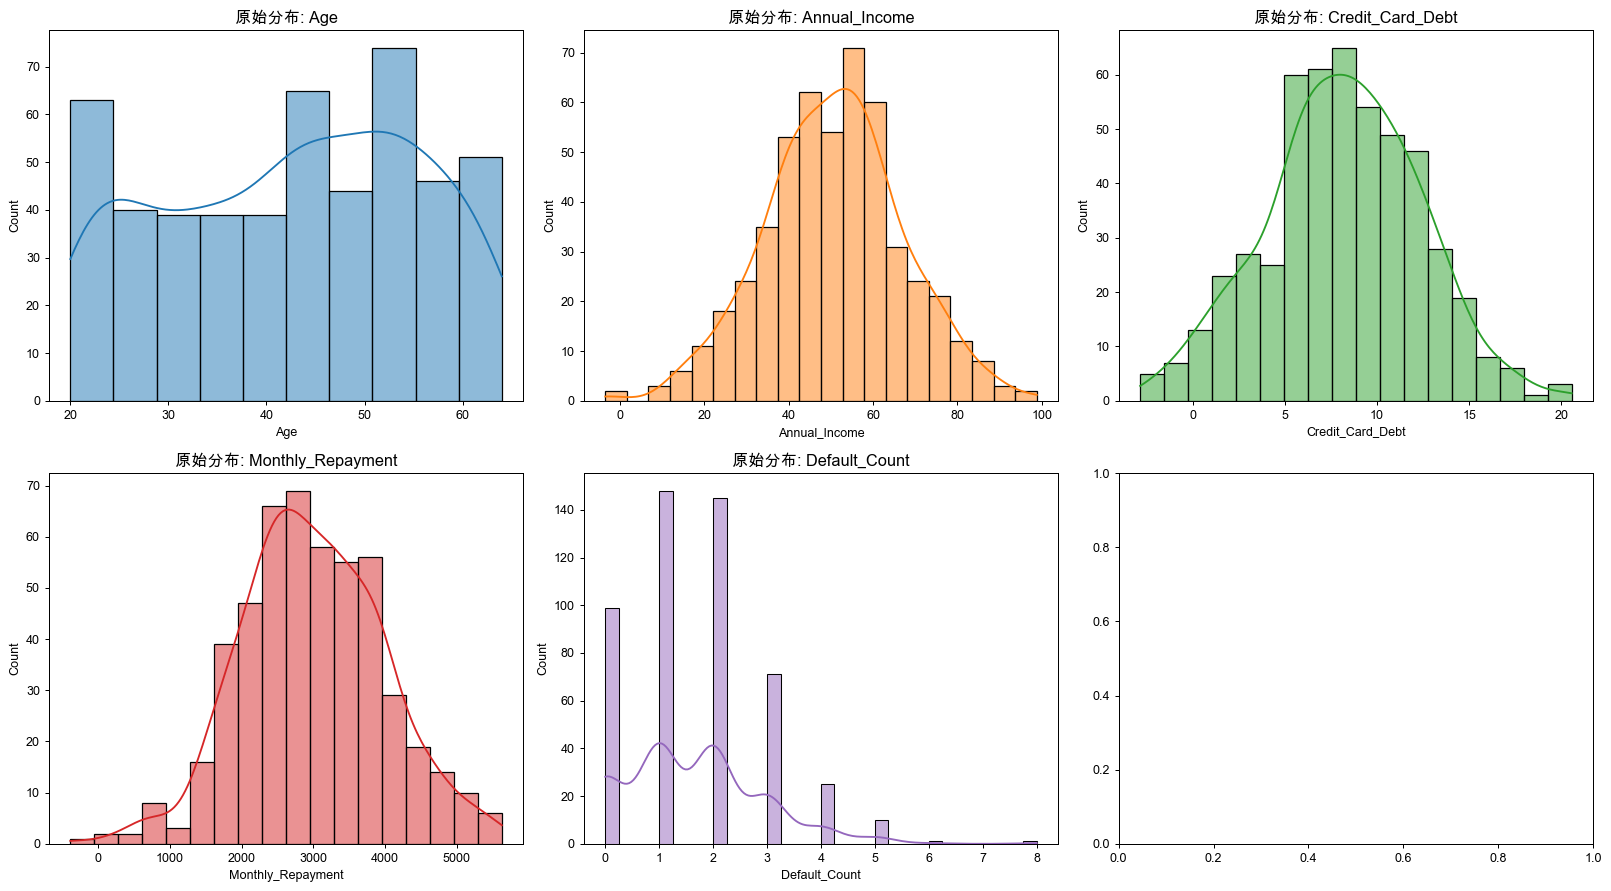

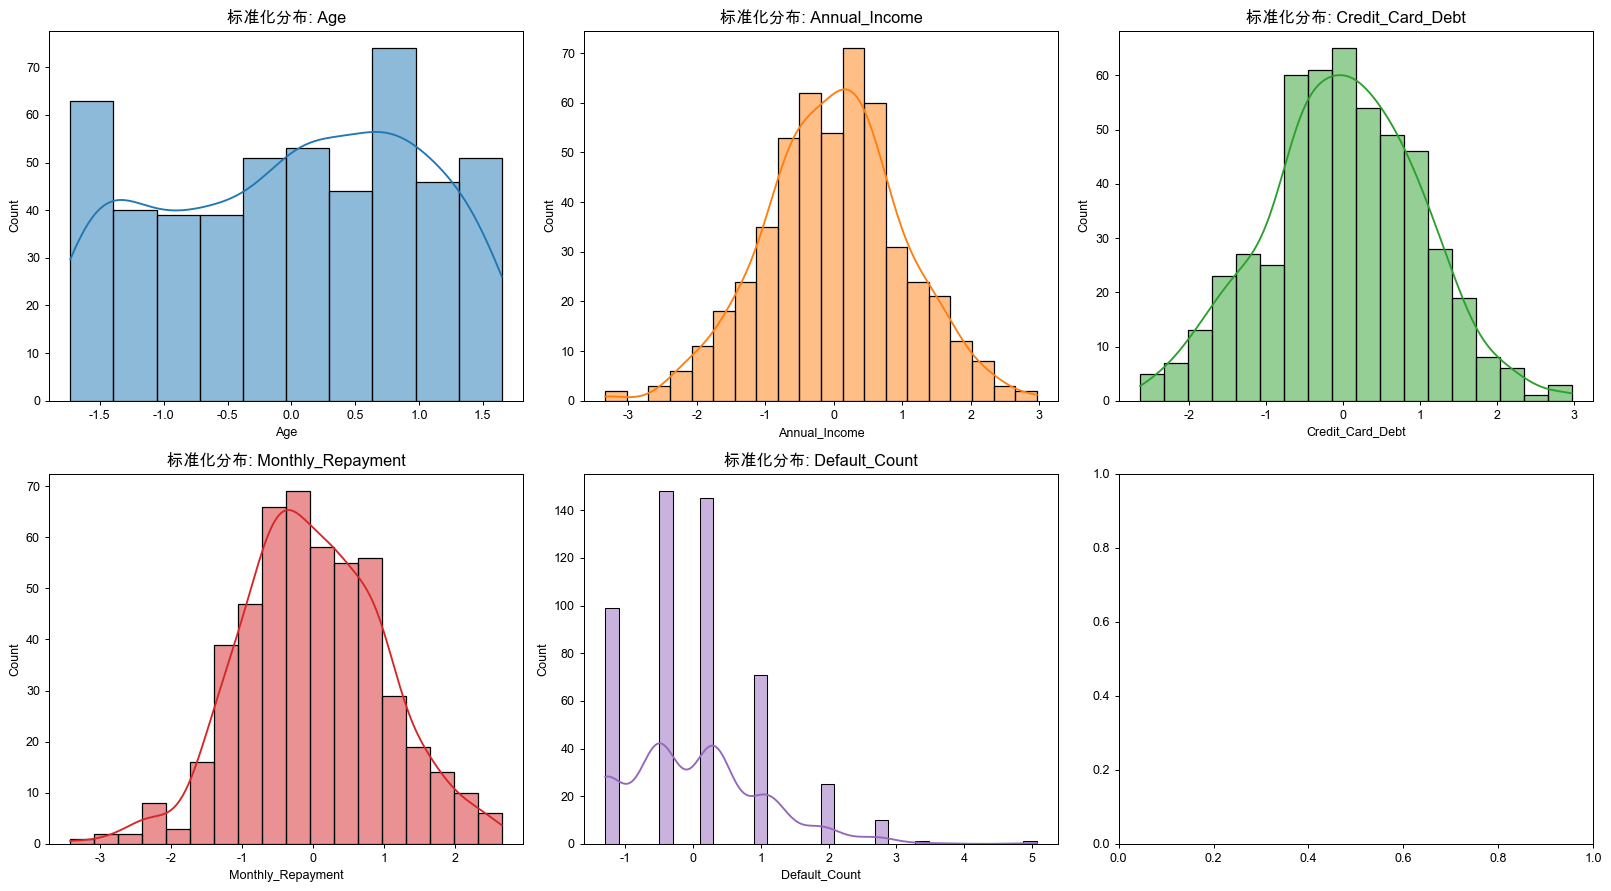

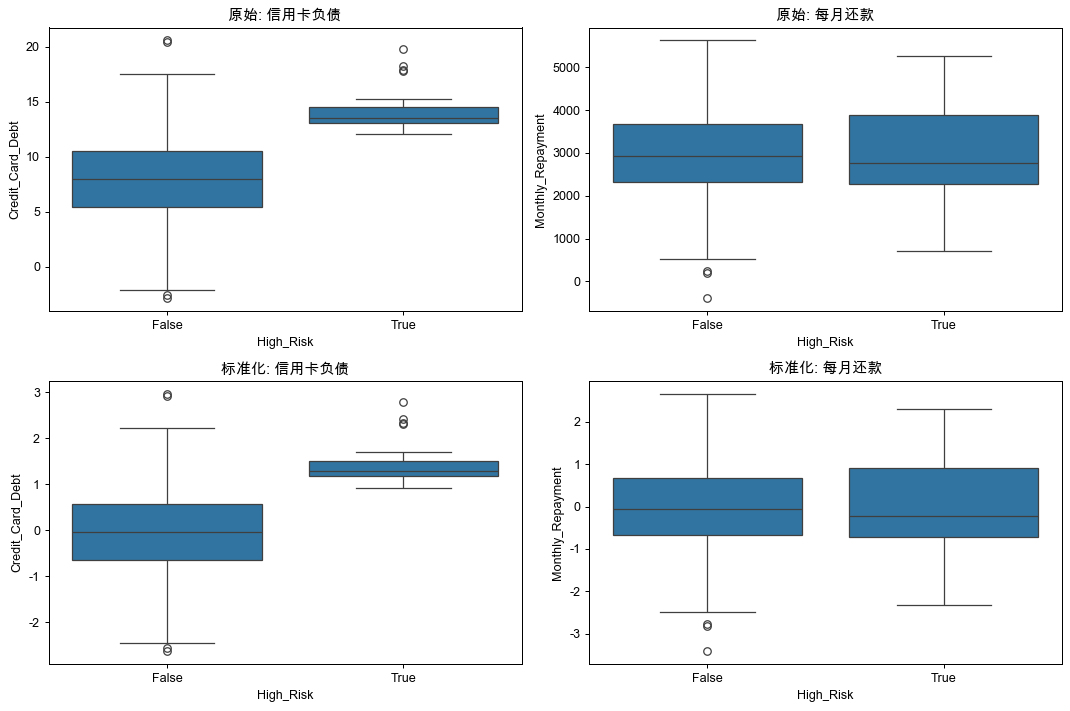

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# 1. 生成模拟数据（含不同量纲）
np.random.seed(42)
n_samples = 500

data = pd.DataFrame({
    'Age': np.random.randint(20, 65, n_samples),
    'Annual_Income': np.random.normal(50, 15, n_samples),        # 单位：万元
    'Credit_Card_Debt': np.random.normal(8, 4, n_samples),        # 单位：万元
    'Monthly_Repayment': np.random.normal(3000, 1000, n_samples), # 单位：元
    'Default_Count': np.random.poisson(1.5, n_samples)            # 次数
})

# 添加目标变量（高风险标记）
data['High_Risk'] = (data['Credit_Card_Debt'] > 12) & (data['Default_Count'] > 2)

# 2. 标准化前的分布可视化
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(data.columns[:-1]):
    sns.histplot(data[col], ax=axes[i], kde=True, color=plt.rcParams["axes.prop_cycle"].by_key()['color'][i])
    axes[i].set_title(f'原始分布: {col}', fontsize=13)

plt.tight_layout()
plt.show()

# 3. 使用 Z-score 标准化
scaler = StandardScaler()
features = data.columns[:-1]
data_scaled = data.copy()
data_scaled[features] = scaler.fit_transform(data[features])

# 4. 标准化后的分布可视化
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(data_scaled.columns[:-1]):
    sns.histplot(data_scaled[col], ax=axes[i], kde=True, color=plt.rcParams["axes.prop_cycle"].by_key()['color'][i])
    axes[i].set_title(f'标准化分布: {col}', fontsize=13)

plt.tight_layout()
plt.show()

# 5. 可视化对比标准化前后的“信用卡负债”和“每月还款”特征
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x='High_Risk', y='Credit_Card_Debt', data=data, ax=axes[0,0])
axes[0,0].set_title("原始: 信用卡负债")
sns.boxplot(x='High_Risk', y='Monthly_Repayment', data=data, ax=axes[0,1])
axes[0,1].set_title("原始: 每月还款")

sns.boxplot(x='High_Risk', y='Credit_Card_Debt', data=data_scaled, ax=axes[1,0])
axes[1,0].set_title("标准化: 信用卡负债")
sns.boxplot(x='High_Risk', y='Monthly_Repayment', data=data_scaled, ax=axes[1,1])
axes[1,1].set_title("标准化: 每月还款")

plt.tight_layout()
plt.show()

#### 1. 数据生成部分

In [3]:
np.random.seed(42)
n_samples = 500

设定随机数种子，确保每次生成的模拟数据一致。

In [4]:
data = pd.DataFrame({
    'Age': np.random.randint(20, 65, n_samples),
    'Annual_Income': np.random.normal(50, 15, n_samples),
    'Credit_Card_Debt': np.random.normal(8, 4, n_samples),
    'Monthly_Repayment': np.random.normal(3000, 1000, n_samples),
    'Default_Count': np.random.poisson(1.5, n_samples)
})

生成模拟的原始数据。每一列的单位不同，数值范围差异极大（这是标准化的基础动因）。

#### 2. 添加风险标签

In [5]:
data['High_Risk'] = (data['Credit_Card_Debt'] > 12) & (data['Default_Count'] > 2)

我们人为设定一个标签：如果一个人信用卡负债高、且违约次数多，我们将其设为「高风险用户」。

#### 3. 原始数据分布可视化

<Axes: xlabel='Default_Count', ylabel='Count'>

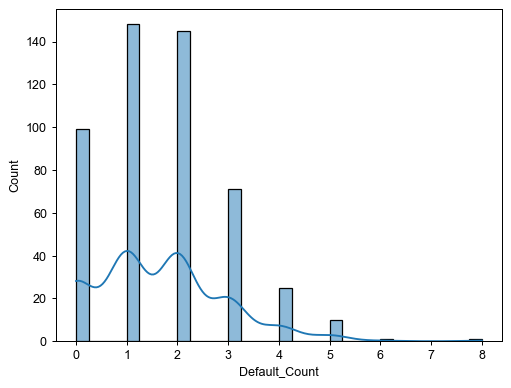

In [6]:
sns.histplot(data[col], kde=True)

画出每个特征原始状态下的分布直方图与密度曲线，可以明显看出：

- 数值量纲不同
- 分布形态不一
- 有的偏态，有的呈正态

![原文参考图，当前结果见代码输出](attachments/img_021.png)

#### 4. 标准化操作（Z-score）

In [7]:
scaler = StandardScaler()
data_scaled[features] = scaler.fit_transform(data[features])

使用 `StandardScaler` 执行 Z-score 标准化，它会自动按：


$$
z = \frac{x - \mu}{\sigma}
$$


转换数据，使其变为：

- 均值 ≈ 0
- 标准差 ≈ 1

![原文参考图，当前结果见代码输出](attachments/img_022.png)

#### 5. 标准化后分布图

重新绘图，观察特征都已经转化成**以0为中心**、**均匀尺度**的标准化分布。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

#### 6. 对比特征对风险标签的影响

<Axes: xlabel='High_Risk', ylabel='Credit_Card_Debt'>

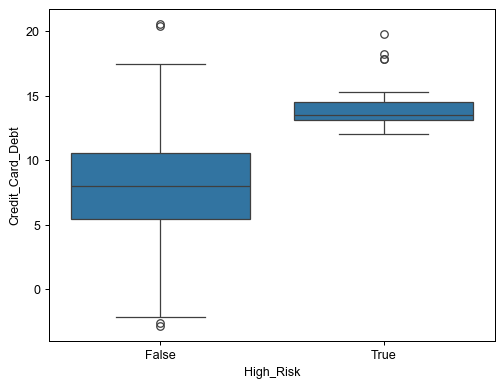

In [8]:
sns.boxplot(x='High_Risk', y='Credit_Card_Debt', data=data)

使用箱线图比较「高风险」与「低风险」用户在某些特征上的区别，在原始数据和标准化数据中对比。

### Z-score 标准化的优缺点

**优点**：

- **消除量纲影响**：将不同量纲的特征统一到一个标准单位上
- **加快模型收敛**：特别适合使用梯度法的模型（如逻辑回归、神经网络）
- **提升算法效果**：对于距离度量敏感的模型（如KNN、SVM）表现更佳
- **便于异常值发现**：Z-score 很容易发现偏离平均值过大的点

**缺点**：

- **对异常值敏感**：极端值会拉高标准差，使得整体分布被“压扁”
- **无法处理非高斯分布**：若原始数据严重偏态，Z-score 处理效果有限
- **需要完整数据集计算均值和方差**，不适合在线场景或分布漂移严重的系统

### Z-score 标准化适用场景

**优选场景**：

1. **特征单位不一致**，但没有严重异常值
2. **数据大致呈正态分布**
3. **使用依赖均值方差的模型**，如：

   - 逻辑回归
   - 线性回归
   - SVM
   - K-means 聚类
   - PCA 主成分分析
   - 神经网络

**不适合**：

1. 特征分布严重偏态（用 log 或 Box-Cox 更合适）
2. 数据中存在大量极端异常值（建议用**RobustScaler**）

## 总结

标准化不仅是数学处理，更是“消除误导”的关键工程步骤。

在后续建模、特征选择、距离计算等环节，Z-score 处理能够显著提升模型稳定性与预测效果。